In [16]:
!pip install jupyterlab ultralytics


In [17]:
from ultralytics import YOLO
import os
import shutil
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import matplotlib.pyplot as plt



In [18]:
import yaml

In [5]:
dataset_path = "C:/Users/Ардак/Documents/3D_object_detection/SpaceVela/data.yaml"

In [11]:
# Проверяем, что файл корректный
with open(dataset_path, 'r') as f:
    data_config = yaml.safe_load(f)
print("Конфигурация датасета:", data_config)

Конфигурация датасета: {'train': '../train/images', 'val': '../valid/images', 'test': '../test/images', 'nc': 1, 'names': ['fail'], 'roboflow': {'workspace': 'dimash', 'project': 'spacevela-3d-cv-1-class-fail', 'version': 16, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/dimash/spacevela-3d-cv-1-class-fail/dataset/16'}}


In [6]:
model = YOLO('yolov8n-seg.pt') 

In [12]:
results = model.train(data=dataset_path, epochs=50, imgsz=640)

Ultralytics 8.3.82  Python-3.11.5 torch-2.6.0+cpu CPU (AMD Ryzen 7 5700U with Radeon Graphics)
engine\trainer: task=segment, mode=train, model=yolov8n-seg.pt, data=C:/Users//Documents/3D_object_detection/SpaceVela/data.yaml, epochs=50, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop

100%|██████████| 755k/755k [00:02<00:00, 307kB/s]

Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

 14             [-1, 4]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 15                  -1  1     37248  ultralytics.nn.modules.block.C2f             [192, 64, 1]                  
 16                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
 17            [-1, 12]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 18                  -1  1    123648  ultralytics.nn.modules.block.C2f             [192, 128, 1]                 
 19                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
 20             [-1, 9]  1         0  ultralytics.nn.modules.conv.Concat           [1]                           
 21                  -1  1    493056  ultralytics.nn.modules.block.C2f             [384, 256, 1]                 
 22        [15, 18, 21]  1   1004275  ultralytics.nn.modules.head.Segment          [1, 3

train: Scanning C:\Users\Ардак\Documents\3D_object_detection\SpaceVela\train\labels... 1043 images, 20 backgrounds, 0 corrupt: 100%|██████████| 1043/1043 [00:01<00:00, 620.60it/s]


...

      50/50         0G       1.72      3.124      1.865      1.555          7        640: 100%|██████████| 66/66 [07:03<00:00,  6.42s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:26<00:00,  6.65s/it]

                   all        127        634        0.4      0.347      0.286      0.107      0.313      0.304      0.205     0.0739



50 epochs completed in 6.536 hours.
Optimizer stripped from runs\segment\train2\weights\last.pt, 6.8MB
Optimizer stripped from runs\segment\train2\weights\best.pt, 6.8MB

Validating runs\segment\train2\weights\best.pt...
Ultralytics 8.3.82  Python-3.11.5 torch-2.6.0+cpu CPU (AMD Ryzen 7 5700U with Radeon Graphics)
YOLOv8n-seg summary (fused): 85 layers, 3,258,259 parameters, 0 gradients, 12.0 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:20<00:00,  5.23s/it]


                   all        127        634      0.402      0.324      0.289      0.104      0.333      0.293      0.212     0.0806
Speed: 1.9ms preprocess, 110.6ms inference, 0.0ms loss, 3.6ms postprocess per image
Results saved to runs\segment\train2


In [7]:
model_path = "runs/segment/train2/weights/best.pt"
print(f"Модель сохранена в {model_path}")

Модель сохранена в runs/segment/train/weights/best.pt


In [10]:
modell = YOLO("runs/segment/train2/weights/best.pt") 

In [12]:
metrics = modell.val()

Ultralytics 8.3.82  Python-3.11.5 torch-2.6.0+cpu CPU (AMD Ryzen 7 5700U with Radeon Graphics)
YOLOv8n-seg summary (fused): 85 layers, 3,258,259 parameters, 0 gradients, 12.0 GFLOPs


val: Scanning C:\Users\Ардак\Documents\3D_object_detection\SpaceVela\valid\labels.cache... 127 images, 0 backgrounds, 0 corrupt: 100%|██████████| 127/127 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:19<00:00,  2.41s/it]


                   all        127        634      0.402      0.324      0.289      0.104      0.333      0.293      0.212     0.0806
Speed: 2.3ms preprocess, 103.6ms inference, 0.0ms loss, 3.4ms postprocess per image
Results saved to runs\segment\val2


In [13]:
print(metrics)

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x00000206B3FDC390>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.0410

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Укажите путь к файлу с логами
csv_path = "runs/segment/train2/results.csv"

# Загрузка данных из CSV
df = pd.read_csv(csv_path)

# Проверка доступных столбцов
print(df.columns)

Index(['epoch', 'time', 'train/box_loss', 'train/seg_loss', 'train/cls_loss',
       'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)',
       'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'metrics/precision(M)',
       'metrics/recall(M)', 'metrics/mAP50(M)', 'metrics/mAP50-95(M)',
       'val/box_loss', 'val/seg_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


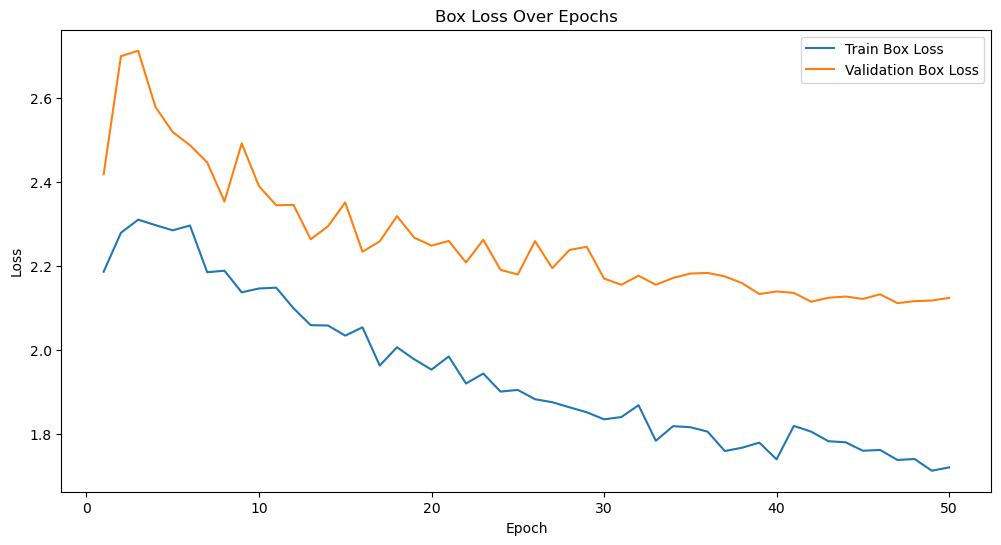

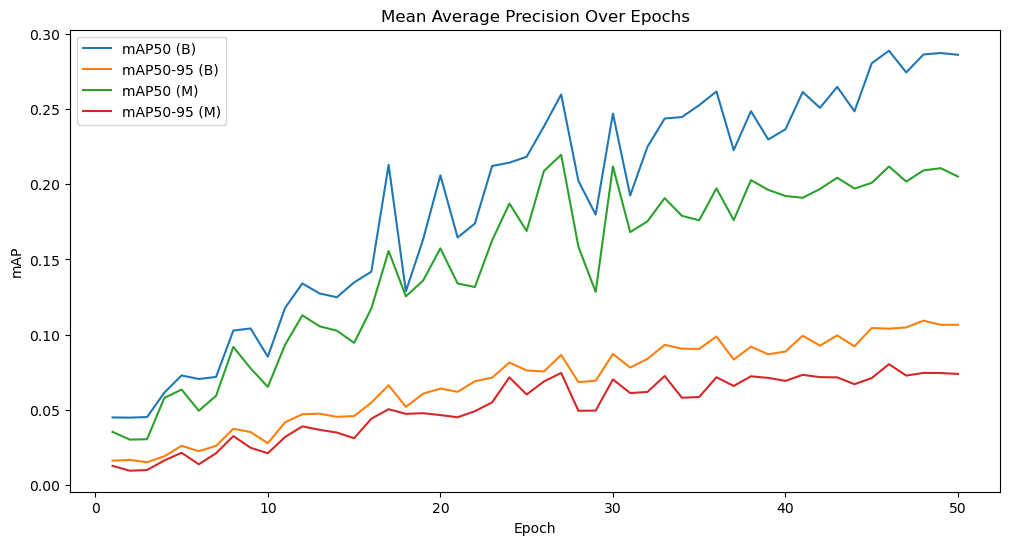

In [27]:
%matplotlib inline


# Построение графиков
plt.figure(figsize=(12, 6))

# График потерь (Loss)
plt.plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
plt.plot(df['epoch'], df['val/box_loss'], label='Validation Box Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Box Loss Over Epochs')
plt.show()

# График mAP (Используем существующие столбцы)
plt.figure(figsize=(12, 6))
plt.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50 (B)')
plt.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95 (B)')
plt.plot(df['epoch'], df['metrics/mAP50(M)'], label='mAP50 (M)')
plt.plot(df['epoch'], df['metrics/mAP50-95(M)'], label='mAP50-95 (M)')
plt.xlabel('Epoch')
plt.ylabel('mAP')
plt.legend()
plt.title('Mean Average Precision Over Epochs')
plt.show()


Index(['epoch', 'time', 'train/box_loss', 'train/seg_loss', 'train/cls_loss',
       'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)',
       'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'metrics/precision(M)',
       'metrics/recall(M)', 'metrics/mAP50(M)', 'metrics/mAP50-95(M)',
       'val/box_loss', 'val/seg_loss', 'val/cls_loss', 'val/dfl_loss',
       'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


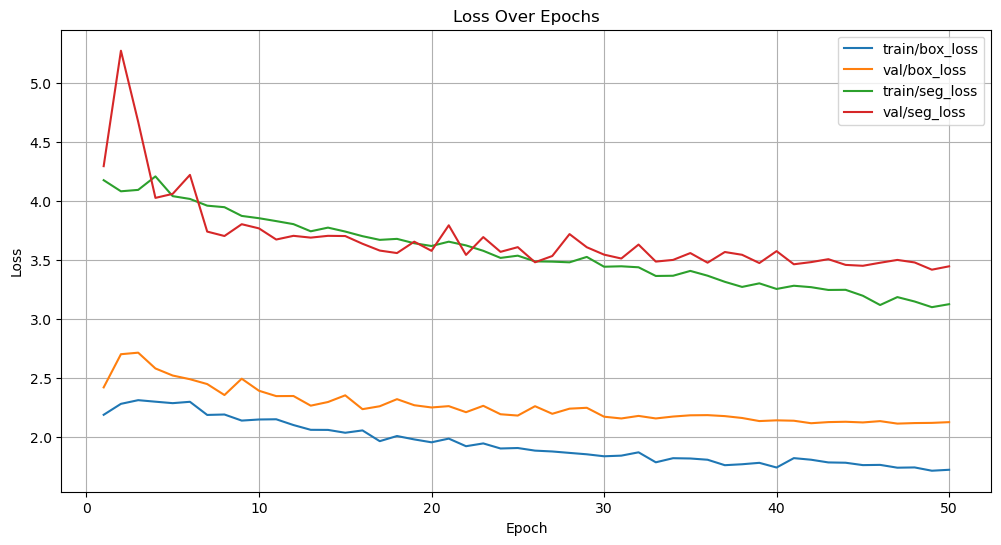

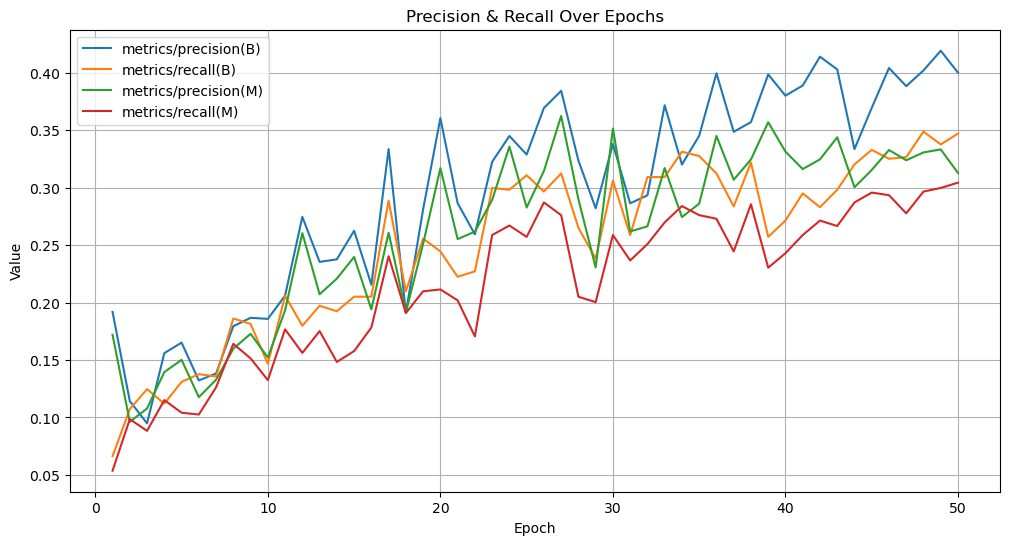

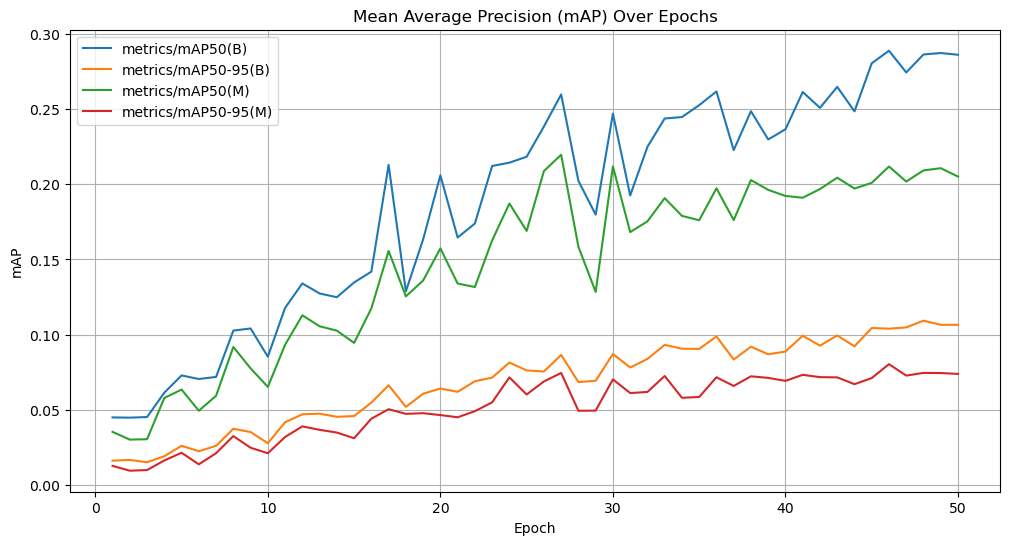

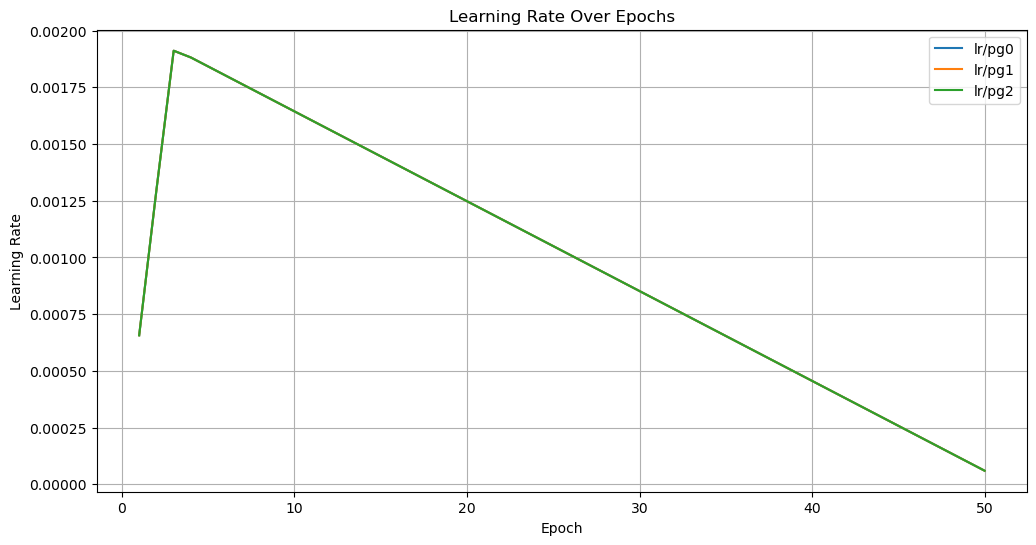

In [28]:



# Проверяем доступные метрики
print(df.columns)

# Функция для построения графика
def plot_metric(df, metrics, title, ylabel):
    plt.figure(figsize=(12, 6))
    for metric in metrics:
        if metric in df.columns:
            plt.plot(df['epoch'], df[metric], label=metric)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.legend()
    plt.title(title)
    plt.grid()
    plt.show()

# Потери (Loss)
plot_metric(df, ['train/box_loss', 'val/box_loss', 'train/seg_loss', 'val/seg_loss'], 
            'Loss Over Epochs', 'Loss')

# Precision и Recall
plot_metric(df, ['metrics/precision(B)', 'metrics/recall(B)', 'metrics/precision(M)', 'metrics/recall(M)'], 
            'Precision & Recall Over Epochs', 'Value')

# Mean Average Precision (mAP)
plot_metric(df, ['metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'metrics/mAP50(M)', 'metrics/mAP50-95(M)'], 
            'Mean Average Precision (mAP) Over Epochs', 'mAP')

# Learning Rate (LR)
plot_metric(df, ['lr/pg0', 'lr/pg1', 'lr/pg2'], 
            'Learning Rate Over Epochs', 'Learning Rate')


In [29]:
best_results = {
    "Best Precision (B)": df.loc[df['metrics/precision(B)'].idxmax(), ['epoch', 'metrics/precision(B)']],
    "Best Recall (B)": df.loc[df['metrics/recall(B)'].idxmax(), ['epoch', 'metrics/recall(B)']],
    "Best mAP50 (B)": df.loc[df['metrics/mAP50(B)'].idxmax(), ['epoch', 'metrics/mAP50(B)']],
    "Best mAP50-95 (B)": df.loc[df['metrics/mAP50-95(B)'].idxmax(), ['epoch', 'metrics/mAP50-95(B)']],
    
    "Best Precision (M)": df.loc[df['metrics/precision(M)'].idxmax(), ['epoch', 'metrics/precision(M)']],
    "Best Recall (M)": df.loc[df['metrics/recall(M)'].idxmax(), ['epoch', 'metrics/recall(M)']],
    "Best mAP50 (M)": df.loc[df['metrics/mAP50(M)'].idxmax(), ['epoch', 'metrics/mAP50(M)']],
    "Best mAP50-95 (M)": df.loc[df['metrics/mAP50-95(M)'].idxmax(), ['epoch', 'metrics/mAP50-95(M)']],

    "Lowest Train Box Loss": df.loc[df['train/box_loss'].idxmin(), ['epoch', 'train/box_loss']],
    "Lowest Validation Box Loss": df.loc[df['val/box_loss'].idxmin(), ['epoch', 'val/box_loss']],
    "Lowest Train Segmentation Loss": df.loc[df['train/seg_loss'].idxmin(), ['epoch', 'train/seg_loss']],
    "Lowest Validation Segmentation Loss": df.loc[df['val/seg_loss'].idxmin(), ['epoch', 'val/seg_loss']],
}

# Выводим лучшие метрики
for key, value in best_results.items():
    print(f"{key}: {value.to_dict()}")

Best Precision (B): {'epoch': 49.0, 'metrics/precision(B)': 0.41909}
Best Recall (B): {'epoch': 48.0, 'metrics/recall(B)': 0.34877}
Best mAP50 (B): {'epoch': 46.0, 'metrics/mAP50(B)': 0.2888}
Best mAP50-95 (B): {'epoch': 48.0, 'metrics/mAP50-95(B)': 0.10934}
Best Precision (M): {'epoch': 27.0, 'metrics/precision(M)': 0.36229}
Best Recall (M): {'epoch': 50.0, 'metrics/recall(M)': 0.3043}
Best mAP50 (M): {'epoch': 27.0, 'metrics/mAP50(M)': 0.21963}
Best mAP50-95 (M): {'epoch': 46.0, 'metrics/mAP50-95(M)': 0.0804}
Lowest Train Box Loss: {'epoch': 49.0, 'train/box_loss': 1.71194}
Lowest Validation Box Loss: {'epoch': 47.0, 'val/box_loss': 2.11131}
Lowest Train Segmentation Loss: {'epoch': 49.0, 'train/seg_loss': 3.09832}
Lowest Validation Segmentation Loss: {'epoch': 49.0, 'val/seg_loss': 3.41607}
